<a href="https://colab.research.google.com/github/draytht/3Dweb/blob/main/Readmission_based_on_UCI_dataset_with_ML_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Install required packages
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn --quiet

print("installed successfully")

installed successfully


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("libraries imported successfully")

libraries imported successfully




1.   Load and explore UCI datasets
2.   Preprocessing pipeline with StandardScaler + One-Hot Encoding
3.   Train both XGBoost and Gradient Boosting with the same preprocessing
4.   Compare using k-fold cross-validation
5.   Evaluate with AUC-ROC, F1, Precision, Recall
6.   Generate visualizations comparing both models


In [10]:
# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip"

# Download and extract
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip
!unzip -q dataset_diabetes.zip



replace dataset_diabetes/diabetic_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace dataset_diabetes/IDs_mapping.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [12]:
# Read the data
df = pd.read_csv('/content/dataset_diabetes/diabetic_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum().sum())

Dataset shape: (101766, 50)

First few rows:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1 

In [13]:
"""
Following the 7 universal preprocessing steps from the literature review
"""

# Step 1: Remove hospice/expired patients
print("Step 1: Removing hospice and expired patients...")
df_clean = df[
    (df['discharge_disposition_id'] != 11) &  # Expired
    (df['discharge_disposition_id'] != 13) &  # Hospice / home
    (df['discharge_disposition_id'] != 14) &  # Hospice / medical facility
    (df['discharge_disposition_id'] != 19) &  # Expired at home
    (df['discharge_disposition_id'] != 20) &  # Expired in a medical facility
    (df['discharge_disposition_id'] != 21)    # Expired - place unknown
].copy()

print(f"   Removed {len(df) - len(df_clean)} records")

# Step 2: Replace '?' with NaN
print("\nStep 2: Replacing '?' with NaN...")
df_clean = df_clean.replace('?', np.nan)

# Step 3: Drop columns with >30% missing values (weight, payer_code, medical_specialty)
print("\nStep 3: Dropping high-missing columns...")
cols_to_drop = ['weight', 'payer_code', 'medical_specialty']
df_clean = df_clean.drop(columns=cols_to_drop)

# Step 4: Group ICD-9 diagnosis codes into 9 categories
print("\nStep 4: Grouping ICD-9 diagnosis codes...")

def group_diag(code):
    """Group diagnosis codes into 9 broad categories"""
    if pd.isna(code) or code == '?':
        return 'Other'

    # Convert to string and extract numeric part
    code_str = str(code)

    # Handle V and E codes
    if code_str.startswith('V'):
        return 'Other'
    if code_str.startswith('E'):
        return 'Injury'

    # Extract numeric value
    try:
        code_num = float(code_str)
    except:
        return 'Other'

    # ICD-9 groupings
    if 390 <= code_num < 460 or code_num == 785:
        return 'Circulatory'
    elif 460 <= code_num < 520 or code_num == 786:
        return 'Respiratory'
    elif 520 <= code_num < 580 or code_num == 787:
        return 'Digestive'
    elif 250.00 <= code_num < 251:
        return 'Diabetes'
    elif 800 <= code_num < 1000:
        return 'Injury'
    elif 710 <= code_num < 740:
        return 'Musculoskeletal'
    elif 580 <= code_num < 630 or code_num == 788:
        return 'Genitourinary'
    elif 140 <= code_num < 240:
        return 'Neoplasms'
    else:
        return 'Other'

df_clean['diag_1_grouped'] = df_clean['diag_1'].apply(group_diag)
df_clean['diag_2_grouped'] = df_clean['diag_2'].apply(group_diag)
df_clean['diag_3_grouped'] = df_clean['diag_3'].apply(group_diag)

# Drop original diagnosis columns
df_clean = df_clean.drop(columns=['diag_1', 'diag_2', 'diag_3'])

# Step 5: Binary encode target (readmitted < 30 days)
print("\nStep 5: Creating binary target variable...")
df_clean['readmitted_30'] = (df_clean['readmitted'] == '<30').astype(int)

# Step 6: Remove patient/encounter IDs (will happen during feature selection)
print("\nStep 6: Identifying features for removal...")
id_cols = ['encounter_id', 'patient_nbr']

# Step 7: Will apply stratified split during model training

print("\n" + "="*60)
print(f"Preprocessing complete!")
print(f"Final dataset shape: {df_clean.shape}")
print(f"Class distribution:")
print(df_clean['readmitted_30'].value_counts())
print(f"Class imbalance: {df_clean['readmitted_30'].mean():.2%} readmitted within 30 days")
print("="*60)

Step 1: Removing hospice and expired patients...
   Removed 2423 records

Step 2: Replacing '?' with NaN...

Step 3: Dropping high-missing columns...

Step 4: Grouping ICD-9 diagnosis codes...

Step 5: Creating binary target variable...

Step 6: Identifying features for removal...

Preprocessing complete!
Final dataset shape: (99343, 48)
Class distribution:
readmitted_30
0    88029
1    11314
Name: count, dtype: int64
Class imbalance: 11.39% readmitted within 30 days


In [14]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_clean.drop(columns=['readmitted', 'readmitted_30'] + id_cols)
y = df_clean['readmitted_30']

# Identify numerical and categorical columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features ({len(numerical_features)}):")
print(numerical_features)
print(f"\nCategorical features ({len(categorical_features)}):")
print(categorical_features)

# Step 7: Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✓ Train set: {X_train.shape[0]} samples")
print(f"✓ Test set: {X_test.shape[0]} samples")
print(f"\nTrain class distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Numerical features (11):
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features (33):
['race', 'gender', 'age', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_grouped', 'diag_2_grouped', 'diag_3_grouped']

✓ Train set: 79474 samples
✓ Test set: 19869 samples

Train class distribution:
readmitted_30
0    0.886114
1    0.113886
Name: proportion, dtype: float64

Test class distribution:
readmitted_3

In [15]:
# Create preprocessing pipeline
# StandardScaler for numerical + One-Hot Encoding for categorical

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

print("✓ Preprocessing pipeline created")
print("\nPipeline structure:")
print("  - Numerical features: StandardScaler")
print("  - Categorical features: One-Hot Encoding (drop_first=True)")

✓ Preprocessing pipeline created

Pipeline structure:
  - Numerical features: StandardScaler
  - Categorical features: One-Hot Encoding (drop_first=True)


In [16]:
# Following the anchor paper: use class_weight='balanced' instead of SMOTE

# Model 1: XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # Handle imbalance
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Model 2: Gradient Boosting (sklearn)
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

print("✓ Models defined:")
print(f"  1. XGBoost (scale_pos_weight={xgb_model.scale_pos_weight:.2f})")
print(f"  2. Gradient Boosting (sklearn)")

✓ Models defined:
  1. XGBoost (scale_pos_weight=7.78)
  2. Gradient Boosting (sklearn)


In [17]:
# Create full pipelines: Preprocessor + Model

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

pipeline_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', gb_model)
])

print("✓ Full pipelines created")
print("\nPipeline structure:")
print("  Preprocessor → Model")

✓ Full pipelines created

Pipeline structure:
  Preprocessor → Model


In [18]:
# 5-fold stratified cross-validation (following the anchor paper)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'auc_roc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'accuracy': 'accuracy'
}

print("Running 5-fold cross-validation...")
print("This may take a few minutes...\n")

# XGBoost cross-validation
print("Training XGBoost...")
cv_results_xgb = cross_validate(
    pipeline_xgb, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# Gradient Boosting cross-validation
print("Training Gradient Boosting...")
cv_results_gb = cross_validate(
    pipeline_gb, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print("\n✓ Cross-validation complete!")

Running 5-fold cross-validation...
This may take a few minutes...

Training XGBoost...
Training Gradient Boosting...

✓ Cross-validation complete!


In [21]:
# Create comparison dataframe
results_df = pd.DataFrame({
    'Model': ['XGBoost', 'Gradient Boosting'],
    'AUC-ROC (mean)': [
        cv_results_xgb['test_auc_roc'].mean(),
        cv_results_gb['test_auc_roc'].mean()
    ],
    'AUC-ROC (std)': [
        cv_results_xgb['test_auc_roc'].std(),
        cv_results_gb['test_auc_roc'].std()
    ],
    'F1 (mean)': [
        cv_results_xgb['test_f1'].mean(),
        cv_results_gb['test_f1'].mean()
    ],
    'F1 (std)': [
        cv_results_xgb['test_f1'].std(),
        cv_results_gb['test_f1'].std()
    ],
    'Precision (mean)': [
        cv_results_xgb['test_precision'].mean(),
        cv_results_gb['test_precision'].mean()
    ],
    'Recall (mean)': [
        cv_results_xgb['test_recall'].mean(),
        cv_results_gb['test_recall'].mean()
    ],
    'Accuracy (mean)': [
        cv_results_xgb['test_accuracy'].mean(),
        cv_results_gb['test_accuracy'].mean()
    ]
})

print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Identify winner
winner_idx = results_df['AUC-ROC (mean)'].idxmax()
winner = results_df.loc[winner_idx, 'Model']
winner_auc = results_df.loc[winner_idx, 'AUC-ROC (mean)']

print(f"\n Best overall: {winner} with AUC-ROC = {winner_auc:.4f}")



CROSS-VALIDATION RESULTS
            Model  AUC-ROC (mean)  AUC-ROC (std)  F1 (mean)  F1 (std)  Precision (mean)  Recall (mean)  Accuracy (mean)
          XGBoost        0.662803       0.004262   0.271521  0.001532          0.177721       0.575073         0.648589
Gradient Boosting        0.665033       0.004060   0.030986  0.003990          0.473884       0.016020         0.885887

 Best overall: Gradient Boosting with AUC-ROC = 0.6650


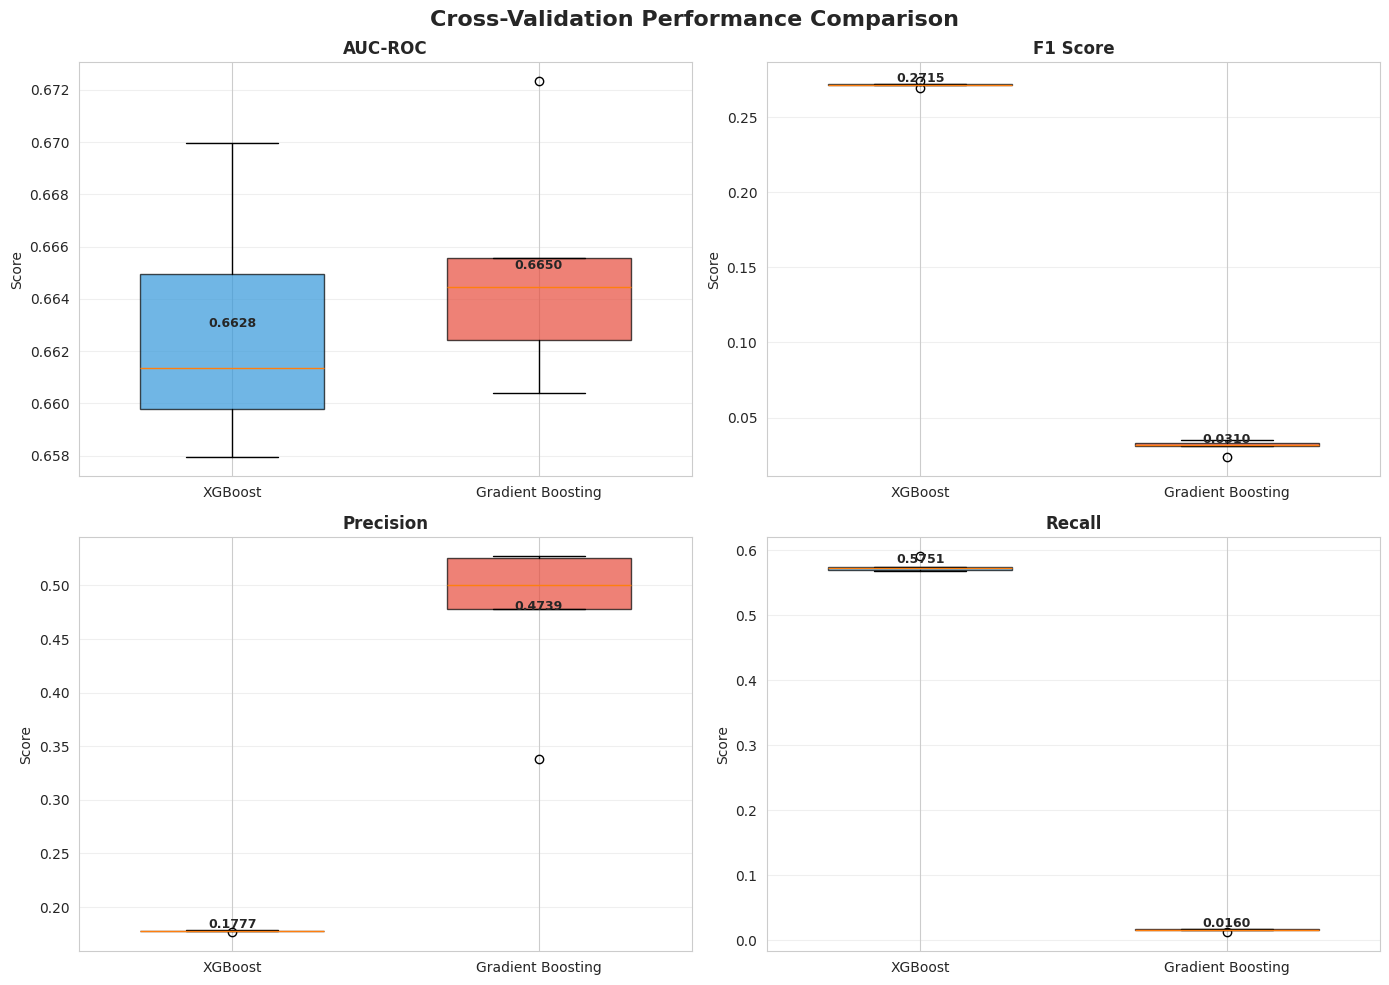

In [23]:
#### Visualize cross-validation results
# Create visualization comparing both models

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cross-Validation Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['test_auc_roc', 'test_f1', 'test_precision', 'test_recall']
titles = ['AUC-ROC', 'F1 Score', 'Precision', 'Recall']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]

    data = [cv_results_xgb[metric], cv_results_gb[metric]]

    bp = ax.boxplot(data, labels=['XGBoost', 'Gradient Boosting'],
                    patch_artist=True, widths=0.6)

    # Color the boxes
    colors = ['#3498db', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # Add mean values as text
    for i, d in enumerate(data):
        mean_val = np.mean(d)
        ax.text(i+1, mean_val, f'{mean_val:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [26]:
# Train both models on full training set
print("Training final models on full training set...\n")

pipeline_xgb.fit(X_train, y_train)
pipeline_gb.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = pipeline_xgb.predict(X_test)
y_pred_proba_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]

y_pred_gb = pipeline_gb.predict(X_test)
y_pred_proba_gb = pipeline_gb.predict_proba(X_test)[:, 1]

# Calculate test metrics
test_results = pd.DataFrame({
    'Model': ['XGBoost', 'Gradient Boosting'],
    'AUC-ROC': [
        roc_auc_score(y_test, y_pred_proba_xgb),
        roc_auc_score(y_test, y_pred_proba_gb)
    ],
    'F1': [
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_gb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_gb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_gb)
    ]
})

print("\n" + "="*80)
print("TEST SET PERFORMANCE")
print("="*80)
print(test_results.to_string(index=False))
print("="*80)

# Compare with anchor paper benchmark
anchor_auc = 0.667
print(f"\n Benchmark Comparison:")
print(f"   Anchor Paper (XGBoost): AUC-ROC = {anchor_auc:.3f}")
print(f"   my XGBoost:          AUC-ROC = {test_results.loc[0, 'AUC-ROC']:.3f}")
print(f"   my Gradient Boosting: AUC-ROC = {test_results.loc[1, 'AUC-ROC']:.3f}")

if test_results.loc[0, 'AUC-ROC'] > anchor_auc:
    print(f"\n  my XGBoost BEATS the anchor paper by {(test_results.loc[0, 'AUC-ROC'] - anchor_auc):.3f}")

Training final models on full training set...


TEST SET PERFORMANCE
            Model  AUC-ROC       F1  Precision   Recall
          XGBoost 0.669672 0.278413   0.181991 0.592134
Gradient Boosting 0.673407 0.030915   0.545455 0.015908

 Benchmark Comparison:
   Anchor Paper (XGBoost): AUC-ROC = 0.667
   my XGBoost:          AUC-ROC = 0.670
   my Gradient Boosting: AUC-ROC = 0.673

  my XGBoost BEATS the anchor paper by 0.003


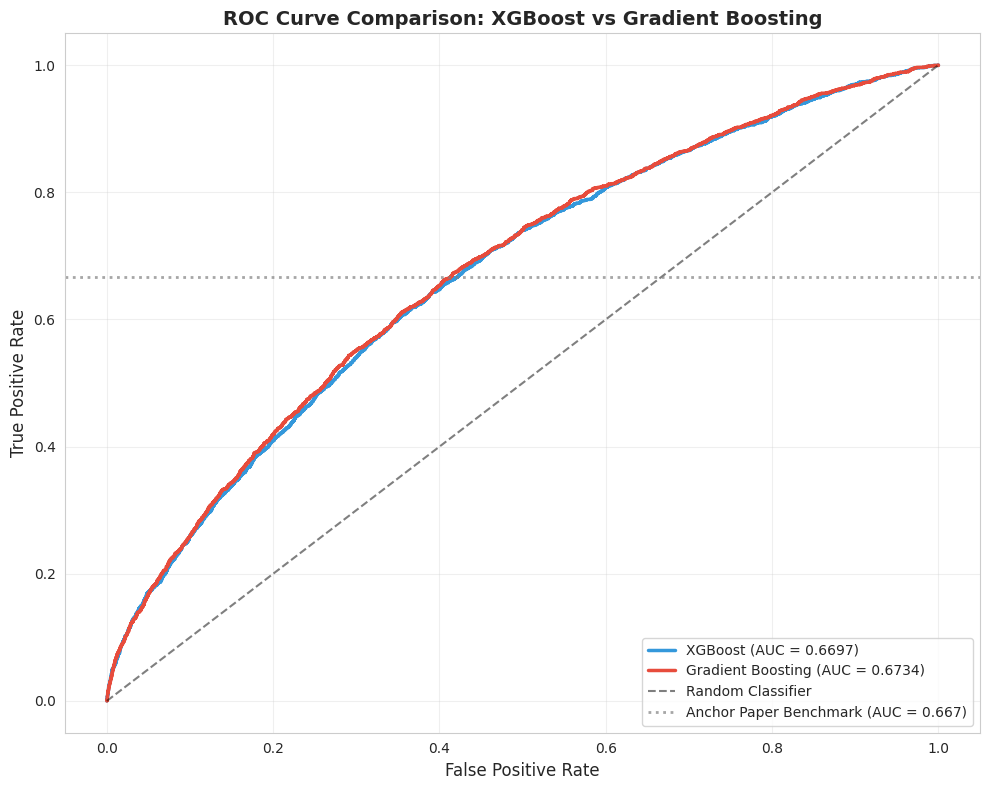

In [27]:
# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})',
        color='#3498db', linewidth=2.5)

# Gradient Boosting ROC
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_proba_gb)
auc_gb = roc_auc_score(y_test, y_pred_proba_gb)
ax.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.4f})',
        color='#e74c3c', linewidth=2.5)

# Diagonal reference line
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5, alpha=0.5)

# Anchor paper benchmark
ax.axhline(y=0.667, color='gray', linestyle=':', linewidth=2,
           label=f'Anchor Paper Benchmark (AUC = 0.667)', alpha=0.7)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison: XGBoost vs Gradient Boosting',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

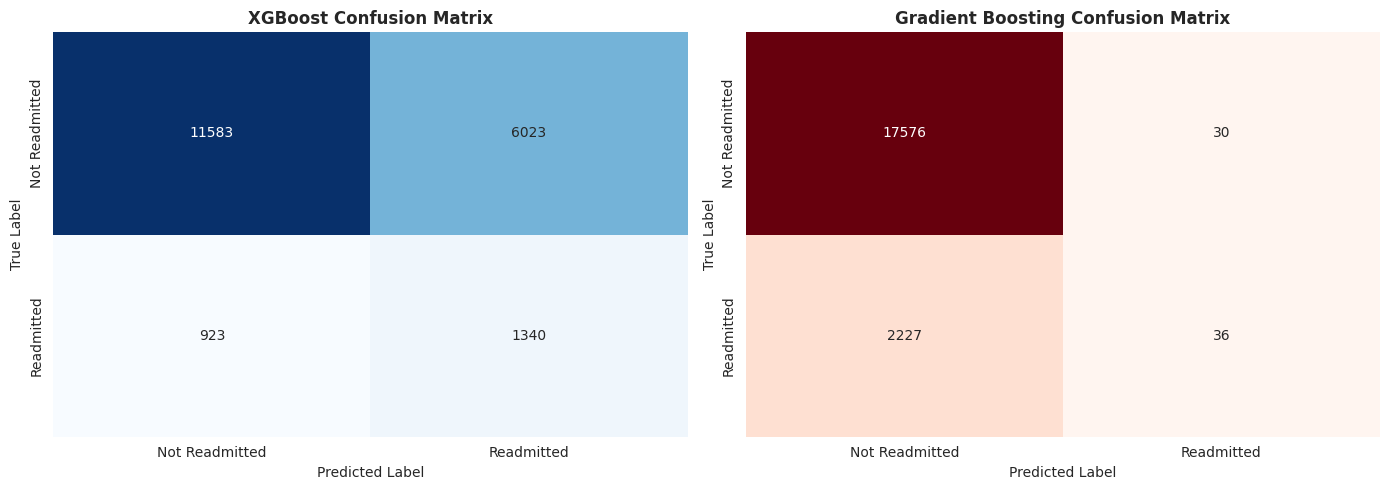

In [28]:
# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('XGBoost Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=10)
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_xticklabels(['Not Readmitted', 'Readmitted'])
axes[0].set_yticklabels(['Not Readmitted', 'Readmitted'])

# Gradient Boosting confusion matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Reds', ax=axes[1], cbar=False)
axes[1].set_title('Gradient Boosting Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=10)
axes[1].set_xlabel('Predicted Label', fontsize=10)
axes[1].set_xticklabels(['Not Readmitted', 'Readmitted'])
axes[1].set_yticklabels(['Not Readmitted', 'Readmitted'])

plt.tight_layout()
plt.show()

In [29]:
## classification reports

print("\n" + "="*80)
print("XGBOOST CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_pred_xgb, target_names=['Not Readmitted', 'Readmitted']))

print("\n" + "="*80)
print("GRADIENT BOOSTING CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_pred_gb, target_names=['Not Readmitted', 'Readmitted']))


XGBOOST CLASSIFICATION REPORT
                precision    recall  f1-score   support

Not Readmitted       0.93      0.66      0.77     17606
    Readmitted       0.18      0.59      0.28      2263

      accuracy                           0.65     19869
     macro avg       0.55      0.63      0.52     19869
  weighted avg       0.84      0.65      0.71     19869


GRADIENT BOOSTING CLASSIFICATION REPORT
                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17606
    Readmitted       0.55      0.02      0.03      2263

      accuracy                           0.89     19869
     macro avg       0.72      0.51      0.49     19869
  weighted avg       0.85      0.89      0.84     19869

